In [ ]:
import os
import math
import random
import re
import string
import math, random, re, gc, torch
import hashlib
from collections import deque
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn import functional as F
from src.model import GPTModel
from src.dataclass import Instance, Task
from src.registry import TASKS
from save_data import save_mixed_trace_file
from tqdm import tqdm

In [ ]:
import os

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random
import numpy as np
import torch



def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)





In [ ]:
import math, random, re, gc
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

from src.model import GPTModel
from src.registry import TASKS


# ============================================================
# CONFIG
# ============================================================

task_name = "word_index"

rho_values = [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
model_seeds = [2000, 2100, 2200]

batch_size = 128
steps = 6000

learning_rate = 3e-3
min_learning_rate = 1e-5
warmup_steps = 600
weight_decay = 0.01
max_grad_norm = 1.0

n_embd = 128
n_head = 4
n_layer = 8
dropout = 0.05

val_batch_size = 256
val_size = 1000

batch_seed = 12345
val_seed = 101

num_workers = 4
USE_COMPILE = True
SAVE_MODELS = False


# ============================================================
# DEVICE / TASK
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    torch.set_float32_matmul_precision("high")

use_bf16 = device == "cuda" and torch.cuda.is_bf16_supported()

task = TASKS[task_name]
tokenizer = task.tokenizer

block_size = task.block_size
max_new_tokens = task.max_new_tokens
pad_id = tokenizer.pad_id
newline_id = tokenizer.newline_id
vocab_size = tokenizer.vocab_size

print("Device:", device)
print("BF16:", use_bf16)
print("Block size:", block_size)
print("Vocab size:", vocab_size)


# ============================================================
# GENERATE FIXED VALIDATION FILE
# ============================================================

train_file = f"{task_name}/{task_name}_rho_0.txt"

with open(train_file, "r", encoding="utf-8") as f:
    train_lines = [line.strip() for line in f if line.strip()]

train_prompts = {line.split(" ", 1)[0] for line in train_lines}

random.seed(val_seed)

val_instances = []
val_prompts = set()

for _ in tqdm(range(val_size), desc="Generate validation"):
    while True:
        inst = task.sample()
        word, c = inst.prompt.split(";")

        assert int(inst.gold) == word.index(c)

        if inst.prompt in train_prompts or inst.prompt in val_prompts:
            continue

        val_instances.append(inst)
        val_prompts.add(inst.prompt)
        break


def get_correct_trace(inst):
    if hasattr(inst, "correct_trace"): return inst.correct_trace
    if hasattr(inst, "correct"): return inst.correct
    return inst[1]


val_file = f"{task_name}/{task_name}_val.txt"

with open(val_file, "w", encoding="utf-8") as f:
    for inst in val_instances:
        f.write(f"{inst.prompt} {get_correct_trace(inst)} : {inst.gold}\n")

print("Saved validation:", val_file)


# ============================================================
# TRAIN DATASET
# ============================================================

class TrainDataset(Dataset):
    def __init__(self, file_path):
        with open(file_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if line.strip()]

        examples = []
        max_len = 0

        for line in tqdm(lines, desc=f"Encoding {file_path}", leave=False):
            prompt, continuation = line.split(" ", 1)

            # Verify FIRST OCCURRENCE
            word, c = prompt.split(";")
            nums = re.findall(r"\d+", continuation.rsplit(":", 1)[1])

            if not nums:
                raise ValueError(f"No gold answer in: {line}")

            assert int(nums[0]) == word.index(c)

            p_ids = tokenizer.encode(prompt)
            t_ids = tokenizer.encode(" " + continuation + "\n")

            full = p_ids + t_ids

            if len(full) > block_size:
                raise ValueError(f"Sequence too long: {len(full)} > {block_size}")

            x = full[:-1]
            y = full[1:]
            mask = [1.0 if i + 1 >= len(p_ids) else 0.0 for i in range(len(x))]

            examples.append((x, y, mask))
            max_len = max(max_len, len(x))

        # Pad everything once here.
        self.xs, self.ys, self.masks = [], [], []

        for x, y, mask in examples:
            pad = max_len - len(x)

            self.xs.append(x + [pad_id] * pad)
            self.ys.append(y + [pad_id] * pad)
            self.masks.append(mask + [0.0] * pad)

        self.xs = torch.tensor(self.xs, dtype=torch.long)
        self.ys = torch.tensor(self.ys, dtype=torch.long)
        self.masks = torch.tensor(self.masks, dtype=torch.float32)

        print("Dataset shape:", tuple(self.xs.shape))

    def __len__(self):
        return len(self.xs)

    def __getitem__(self, idx):
        return self.xs[idx], self.ys[idx], self.masks[idx]


# ============================================================
# VALIDATION DATASET
# ============================================================

class ValDataset(Dataset):
    def __init__(self, file_path):
        with open(file_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if line.strip()]

        self.items = []

        for line in lines:
            prompt, continuation = line.split(" ", 1)

            nums = re.findall(r"\d+", continuation.rsplit(":", 1)[1])

            if not nums:
                raise ValueError(f"No gold answer in validation line: {line}")

            gold = nums[0]
            word, c = prompt.split(";")

            assert int(gold) == word.index(c)

            prompt_ids = tokenizer.encode(prompt)

            if len(prompt_ids) > block_size:
                raise ValueError(f"Validation prompt too long: {prompt}")

            self.items.append((prompt, gold, prompt_ids))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        return self.items[idx]


val_dataset = ValDataset(val_file)

print("Validation examples:", len(val_dataset))


# ============================================================
# VALIDATION DATALOADERS BY LENGTH
#
# We keep equal prompt lengths together because generate()
# should not receive right-padded prompts.
# ============================================================

val_by_length = {}

for i in range(len(val_dataset)):
    prompt, gold, ids = val_dataset[i]
    val_by_length.setdefault(len(ids), []).append((prompt, gold, ids))


def make_val_loader(items):
    class BucketDataset(Dataset):
        def __len__(self): return len(items)

        def __getitem__(self, idx):
            prompt, gold, ids = items[idx]
            return torch.tensor(ids, dtype=torch.long), prompt, gold

    return DataLoader(
        BucketDataset(),
        batch_size=val_batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(device == "cuda")
    )


val_loaders = {length: make_val_loader(items) for length, items in val_by_length.items()}

print("Validation token-length buckets:", {k: len(v) for k, v in val_by_length.items()})


# ============================================================
# LEARNING RATE
# ============================================================

def get_lr(step):
    if step < warmup_steps:
        return learning_rate * (step + 1) / warmup_steps

    decay = (step - warmup_steps) / (steps - warmup_steps)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay))

    return min_learning_rate + coeff * (learning_rate - min_learning_rate)


# ============================================================
# EVALUATION
# ============================================================

def evaluate_model(model, rho, model_seed):
    model.eval()

    correct = 0
    separator_count = 0
    total = 0

    total_batches = sum(len(loader) for loader in val_loaders.values())

    with torch.inference_mode():
        with tqdm(total=total_batches, desc=f"Val rho={rho:.2f} seed={model_seed}", leave=False) as bar:

            for prompt_len, loader in sorted(val_loaders.items()):

                for context, prompts, golds in loader:
                    context = context.to(device, non_blocking=True)

                    out = model.generate(
                        context,
                        max_new_tokens=max_new_tokens,
                        stop_id=newline_id,
                        greedy=True
                    )

                    for row, gold in zip(out.tolist(), golds):
                        generated_ids = row[prompt_len:]
                        generated = tokenizer.decode(generated_ids).split("\n", 1)[0]

                        pred = None

                        if ":" in generated:
                            separator_count += 1
                            nums = re.findall(r"\d+", generated.rsplit(":", 1)[1])

                            if nums:
                                pred = nums[0]

                        correct += int(pred == gold)
                        total += 1

                    bar.update(1)

    return correct / total, separator_count / total


# ============================================================
# RESULTS
# ============================================================

all_accuracies = {rho: [] for rho in rho_values}
all_separator_rates = {rho: [] for rho in rho_values}


# ============================================================
# MAIN EXPERIMENT
# ============================================================

for rho in rho_values:

    print("\n" + "=" * 70)
    print(f"RHO = {rho:.2f}")
    print("=" * 70)

    data_file = f"{task_name}/{task_name}_rho_{int(round(rho * 100))}.txt"

    # --------------------------------------------------------
    # Encode dataset ONCE per rho
    # --------------------------------------------------------

    train_dataset = TrainDataset(data_file)


    for model_seed in model_seeds:

        print(f"\nrho={rho:.2f} | seed={model_seed}")

        random.seed(model_seed)
        np.random.seed(model_seed)
        torch.manual_seed(model_seed)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(model_seed)


        # ====================================================
        # DATALOADER
        # ====================================================

        loader_generator = torch.Generator()
        loader_generator.manual_seed(batch_seed)

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            drop_last=True,
            num_workers=num_workers,
            pin_memory=(device == "cuda"),
            persistent_workers=(num_workers > 0),
            generator=loader_generator
        )


        # ====================================================
        # MODEL
        # ====================================================

        base_model = GPTModel(
            vocab_size=vocab_size,
            block_size=block_size,
            pad_id=pad_id,
            n_embd=n_embd,
            n_head=n_head,
            n_layer=n_layer,
            dropout=dropout
        ).to(device)

        model = torch.compile(base_model, mode="reduce-overhead") if USE_COMPILE and device == "cuda" else base_model


        # ====================================================
        # OPTIMIZER
        # ====================================================

        try:
            optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=learning_rate,
                weight_decay=weight_decay,
                fused=(device == "cuda")
            )
        except Exception:
            optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=learning_rate,
                weight_decay=weight_decay
            )


        # ====================================================
        # TRAIN
        # ====================================================

        model.train()

        train_iter = iter(train_loader)

        for step in tqdm(range(steps), desc=f"Train rho={rho:.2f} seed={model_seed}", leave=False):

            try:
                xb, yb, mb = next(train_iter)
            except StopIteration:
                train_iter = iter(train_loader)
                xb, yb, mb = next(train_iter)

            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            mb = mb.to(device, non_blocking=True)

            lr = get_lr(step)

            for group in optimizer.param_groups:
                group["lr"] = lr

            optimizer.zero_grad(set_to_none=True)

            if use_bf16:
                with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                    _, loss = model(xb, targets=yb, mask=mb)
            else:
                _, loss = model(xb, targets=yb, mask=mb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()


        # ====================================================
        # VALIDATION
        # ====================================================

        val_acc, separator_rate = evaluate_model(base_model, rho, model_seed)

        all_accuracies[rho].append(val_acc)
        all_separator_rates[rho].append(separator_rate)

        print(
            f"rho={rho:.2f} | seed={model_seed} | "
            f"accuracy={val_acc * 100:.2f}% | "
            f"separator={separator_rate * 100:.2f}%"
        )


        # ====================================================
        # OPTIONAL SAVE
        # ====================================================

        if SAVE_MODELS:
            path = f"{task_name}/{task_name}_rho_{int(round(rho * 100))}_seed_{model_seed}.pt"
            torch.save(base_model.state_dict(), path)


        # ====================================================
        # CLEANUP
        # ====================================================

        del train_iter, train_loader, model, base_model, optimizer, loader_generator

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


    del train_dataset

    gc.collect()


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n" + "=" * 80)
print("FINAL RESULTS")
print("=" * 80)

for rho in rho_values:
    values = np.array(all_accuracies[rho]) * 100

    mean = values.mean()
    std = values.std(ddof=1) if len(values) > 1 else 0.0

    print(
        f"rho={rho:.2f} | "
        f"mean={mean:.2f}% | "
        f"std={std:.2f}% | "
        f"runs={values}"
    )

Device: cuda
BF16: True
Block size: 128
Vocab size: 46


Generate validation:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved validation: word_index/word_index_val.txt
Validation examples: 1000
Validation token-length buckets: {12: 141, 14: 124, 10: 137, 11: 105, 9: 136, 16: 121, 13: 114, 15: 122}

RHO = 0.00


Encoding word_index/word_index_rho_0.txt:   0%|          | 0/599998 [00:00<?, ?it/s]

Dataset shape: (599998, 67)

rho=0.00 | seed=2000


...

Val rho=1.00 seed=2100:   0%|          | 0/8 [00:00<?, ?it/s]

rho=1.00 | seed=2100 | accuracy=96.20% | separator=100.00%

rho=1.00 | seed=2200


Train rho=1.00 seed=2200:   0%|          | 0/6000 [00:00<?, ?it/s]

Val rho=1.00 seed=2200:   0%|          | 0/8 [00:00<?, ?it/s]

rho=1.00 | seed=2200 | accuracy=96.20% | separator=100.00%

FINAL RESULTS
rho=0.00 | mean=12.03% | std=0.81% | runs=[12.9 11.3 11.9]
rho=0.20 | mean=68.47% | std=48.04% | runs=[13.  96.2 96.2]
rho=0.30 | mean=96.20% | std=0.00% | runs=[96.2 96.2 96.2]
rho=0.40 | mean=96.20% | std=0.00% | runs=[96.2 96.2 96.2]
rho=0.50 | mean=96.20% | std=0.00% | runs=[96.2 96.2 96.2]
rho=0.60 | mean=96.20% | std=0.00% | runs=[96.2 96.2 96.2]
rho=0.70 | mean=96.20% | std=0.00% | runs=[96.2 96.2 96.2]
rho=0.80 | mean=96.20% | std=0.00% | runs=[96.2 96.2 96.2]
rho=1.00 | mean=96.20% | std=0.00% | runs=[96.2 96.2 96.2]


In [4]:
import numpy as np

mean_acc = []
std_acc = []

print("\n" + "=" * 70)
print("RESULTS")
print("=" * 70)

for rho in rho_values:

    values = np.array(all_accuracies[rho]) * 100

    mean = values.mean()
    std = values.std(ddof=1)

    mean_acc.append(mean)
    std_acc.append(std)

    print(
        f"ρ={rho:.2f} | "
        f"mean={mean:.2f}% | "
        f"std={std:.2f}% | "
        f"runs={values}"
    )


RESULTS
ρ=0.00 | mean=12.03% | std=0.81% | runs=[12.9 11.3 11.9]
ρ=0.20 | mean=68.47% | std=48.04% | runs=[13.  96.2 96.2]
ρ=0.30 | mean=96.20% | std=0.00% | runs=[96.2 96.2 96.2]
ρ=0.40 | mean=96.20% | std=0.00% | runs=[96.2 96.2 96.2]
ρ=0.50 | mean=96.20% | std=0.00% | runs=[96.2 96.2 96.2]
ρ=0.60 | mean=96.20% | std=0.00% | runs=[96.2 96.2 96.2]
ρ=0.70 | mean=96.20% | std=0.00% | runs=[96.2 96.2 96.2]
ρ=0.80 | mean=96.20% | std=0.00% | runs=[96.2 96.2 96.2]
ρ=1.00 | mean=96.20% | std=0.00% | runs=[96.2 96.2 96.2]


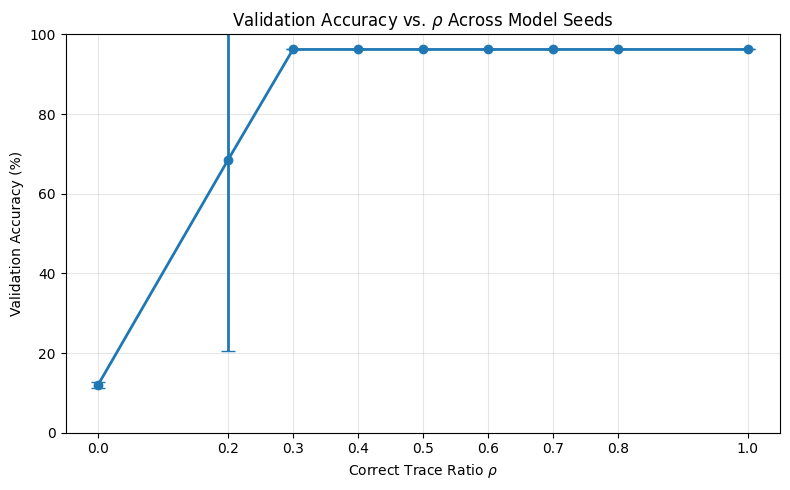

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.errorbar(
    rho_values,
    mean_acc,
    yerr=std_acc,
    marker="o",
    capsize=5,
    linewidth=2
)

plt.xlabel(r"Correct Trace Ratio $\rho$")
plt.ylabel("Validation Accuracy (%)")
plt.title(r"Validation Accuracy vs. $\rho$ Across Model Seeds")

plt.xticks(rho_values)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

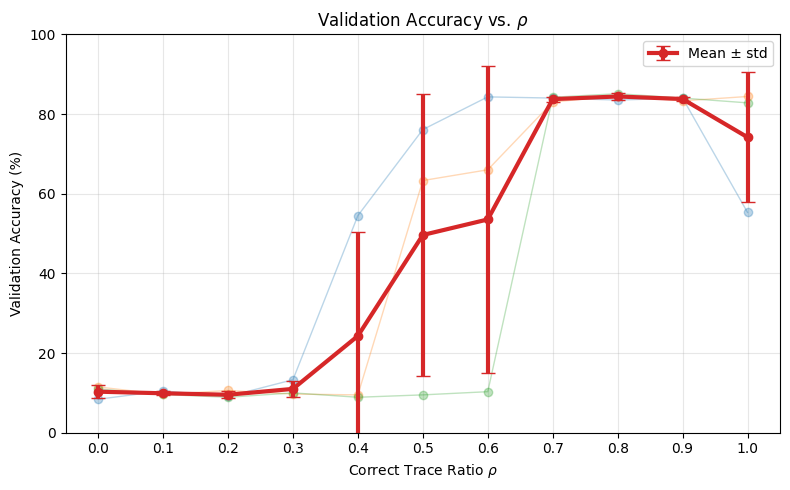

In [8]:
import matplotlib.pyplot as plt
import numpy as np

mean_acc = []
std_acc = []

for rho in rho_values:
    values = np.array(all_accuracies[rho]) * 100
    mean_acc.append(values.mean())
    std_acc.append(values.std(ddof=1))


plt.figure(figsize=(8, 5))

for j in range(len(model_seeds)):
    seed_acc = [100 * all_accuracies[rho][j] for rho in rho_values]
    plt.plot(rho_values, seed_acc, marker="o", alpha=0.3, linewidth=1)


plt.errorbar(
    rho_values,
    mean_acc,
    yerr=std_acc,
    marker="o",
    linewidth=3,
    capsize=5,
    label="Mean ± std"
)


plt.xlabel(r"Correct Trace Ratio $\rho$")
plt.ylabel("Validation Accuracy (%)")
plt.title(r"Validation Accuracy vs. $\rho$")

plt.xticks(rho_values)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()